## Creating a Linear Regression Model

### Discovery

Welcome new data analyst contractor, to Ethical Oil Inc. Whilst on your generous and extremely interesting 30 second induction, your IT systems have been fully set up, tested and everything is working perfectly. <br><br>
As your first task, you have been tasked with trying to determine if there is a linear relationship between the cost of oil and the S&P 500 valuation. You will use a linear regression model to establish if any relationship exists and if so, how oil prices are impacted by stock market fluctuations. Data has already been sourced by the ever efficient and humble management team.

First we will import the required modules. They are:
- pandas
- seaborn
- statsmodels.api
- sklearn.model_selection - train_test_split

In [2]:
# Import required modules
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

--- 
### Data preparation
Import the stocks dataset. Set the index column as the "Date". Remember to validate the import has worked.

In [6]:
# Import the first dataset and set the date as the index
gen_df = pd.read_csv("tnuos_generation_onshore.csv")
# stock_df = pd.read_csv("all_stocks_5yr.csv")
gen_df.tail(10)

,Publication,Year_FY,Published_Date,Zone_No,Zone_Name,SystemPeak_£/kW,SharedYearRound_£/kW,NotSharedYearRound_£/kW,Residual_£/kW,SmallGenDiscount_£/kW
1124,Final,2021,31/01/2020,18,Mid Wales and The Midlands,1.028830,1.033194,0.000000,-4.849145,11.545625
1125,Final,2021,31/01/2020,19,Anglesey and Snowdon,3.476508,1.651390,0.000000,-4.849145,11.545625
1126,Final,2021,31/01/2020,20,Pembrokeshire,9.116666,-4.819420,0.000000,-4.849145,11.545625
1127,Final,2021,31/01/2020,21,South Wales & Gloucester,5.844645,-4.941232,0.000000,-4.849145,11.545625
1128,Final,2021,31/01/2020,22,Cotswold,2.544754,2.902551,-7.885646,-4.849145,11.545625
1129,Final,2021,31/01/2020,23,Central London,-5.772175,2.902551,-7.139875,-4.849145,11.545625
1130,Final,2021,31/01/2020,24,Essex and Kent,-3.806958,2.902551,0.000000,-4.849145,11.545625
1131,Final,2021,31/01/2020,25,"Oxfordshire, Surrey and Sussex",-0.933476,-2.366475,0.000000,-4.849145,11.545625
1132,Final,2021,31/01/2020,26,Somerset and Wessex,-1.796550,-3.216596,0.000000,-4.849145,11.545625
1133,Final,2021,31/01/2020,27,West Devon and Cornwall,-0.261549,-5.784184,0.000000,-4.849145,11.545625


In [9]:
# Removed unrequired data and renamed close price
gen_df = gen_df[["SystemPeak_£/kW","SharedYearRound_£/kW", "NotSharedYearRound_£/kW","Residual_£/kW","SmallGenDiscount_£/kW"]]
gen_df.head()


,SystemPeak_£/kW,SharedYearRound_£/kW,NotSharedYearRound_£/kW,Residual_£/kW,SmallGenDiscount_£/kW
0,3.628060,26.532717,17.674559,-2.47676,0.0
1,5.307833,14.646253,17.674559,-2.47676,0.0
2,3.677990,26.123017,17.385831,-2.47676,0.0
3,3.612174,26.123017,24.924783,-2.47676,0.0
4,6.568239,20.511538,12.542262,-2.47676,0.0


Import the oil dataset, set the index column as "date". Remember to validate teh import has worked. 

--- 
### Model planning
You will now need to understand which variables have a relationship from the prepared data. Identifying the strength and direction of the relationships will help you to build a useful model, within the remit of the task. 

Create a correlation matrix, to establish which variables you wish to use. We will only use 1 indepednent and 1 depedant variable for this model. 

<Axes: >

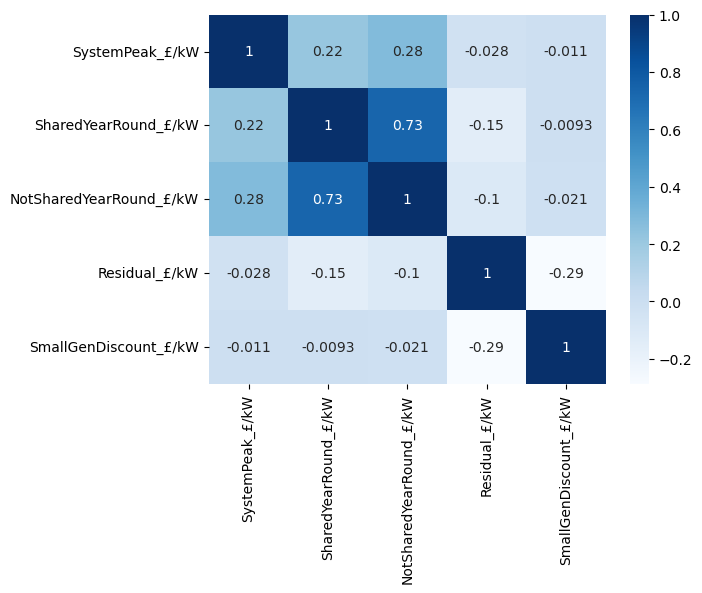

In [10]:
# Use price as dependent and select another appropriate variable to predict the output. 
gen_corr = gen_df.corr()
#join_corr
sns.heatmap(gen_corr, annot=True, cmap="Blues")

Create a Regplot/Scatterplot to demonstrate the relationship between our dependent and independent variable. 

<Axes: xlabel='SharedYearRound_£/kW', ylabel='NotSharedYearRound_£/kW'>

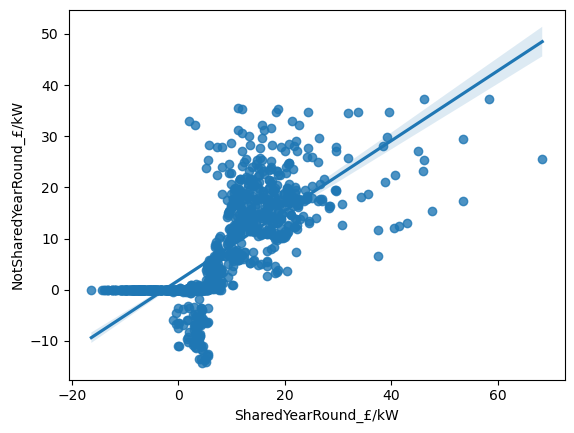

In [12]:
# Check the relationship between the selected variables
sns.regplot(x = "SharedYearRound_£/kW",
            y = "NotSharedYearRound_£/kW",
            data = gen_df)

---
### Building the model
Split the data into training and test datasets - include the random_state argument:<br>
random_state = 25

In [46]:
# Split the data into train and test samples
train, test = train_test_split(join_df,random_state=25)

Set both the independent variable and dependent variable - remember to check they are set correctly. Don't forget to add a constant to your independent variables. 

In [47]:
# Set the dependent variable and validate
dep = train["Oil Cost $ (Barrell)"]
dep.head()

2015-05-01     60.30
2017-10-01     54.38
2013-08-01    107.65
2016-02-01     33.75
2014-01-01     97.49
Name: Oil Cost $ (Barrell), dtype: float64

In [48]:
# Set the independent variable and validate
ind = train["S&P Close Price $"]
ind.head()

2015-05-01     85.705089
2017-10-01    102.908070
2013-08-01     64.504099
2016-02-01     76.983138
2014-01-01     71.825667
Name: S&P Close Price $, dtype: float64

In [49]:
# Remember to add the constant 
ind = sm.add_constant(ind)
ind.head()

,const,S&P Close Price $
2015-05-01,1.0,85.705089
2017-10-01,1.0,102.908070
2013-08-01,1.0,64.504099
2016-02-01,1.0,76.983138
2014-01-01,1.0,71.825667


Now generate the model along with a summary output. 

In [50]:
# Fit the model and produce the summary
model = sm.OLS(dep,ind).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     Oil Cost $ (Barrell)   R-squared:                       0.498
Model:                              OLS   Adj. R-squared:                  0.487
Method:                   Least Squares   F-statistic:                     42.71
Date:                  Wed, 08 Apr 2026   Prob (F-statistic):           6.08e-08
Time:                          15:19:42   Log-Likelihood:                -189.39
No. Observations:                    45   AIC:                             382.8
Df Residuals:                        43   BIC:                             386.4
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               175.7521     16.942     10.374      0.000     141.585     209.919
S&P Close Price $    -1.3205      0.202     -6.535      0.000      -1.728      -0.913
==============================================================================
Omnibus:                        0.024   Durbin-Watson:                   2.058
Prob(Omnibus):                  0.988   Jarque-Bera (JB):                0.203
Skew:                          -0.010   Prob(JB):                        0.903
Kurtosis:                       2.671   Cond. No.                         572.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

--- 
### Communicating the results. 
You will now analyse the model and communicate the results. What do the following outputs tell you about the model

- R-Squared: 
- F-Statistic: 
- Prob (F-Statistic):
- P-Value:
- Coefficient:
- Constant:

Now lets test the model output - remember to add a constant to your test data. 

In [51]:
# Set the test sample independent variable and use the model to predict the variable, using the test dataset 
test_ind = test[["S&P Close Price $"]]
test_ind = sm.add_constant(test_ind)
output = model.predict(test_ind)

Finally, add a predicted column to your test dataset, where you have your prediction shown, alongside your actual values for your dependent variable. 

In [52]:
# Add the predicted values to our test dataframe to compare actual with predicted. 
test["predicted"] = output
test[["Oil Cost $ (Barrell)","S&P Close Price $","predicted"]]
#test = pd.to_csv("outputdata")

,Oil Cost $ (Barrell),S&P Close Price $,predicted
2014-02-01,102.59,72.859147,79.543491
2014-03-01,101.58,74.899410,76.849376
2014-04-01,99.74,74.578316,77.273373
2014-09-01,91.16,79.037900,71.384607
2013-09-01,102.33,65.744264,88.938510
2016-01-01,33.62,77.898386,72.889307
2016-04-01,45.92,84.534876,64.125993
2015-07-01,47.12,85.227152,63.211861
2016-07-01,41.60,87.679289,59.973877
2017-09-01,51.67,100.133291,43.528690


Now you have genereated some predictions with the test data, explain the output by way of the formula Y = mX + C

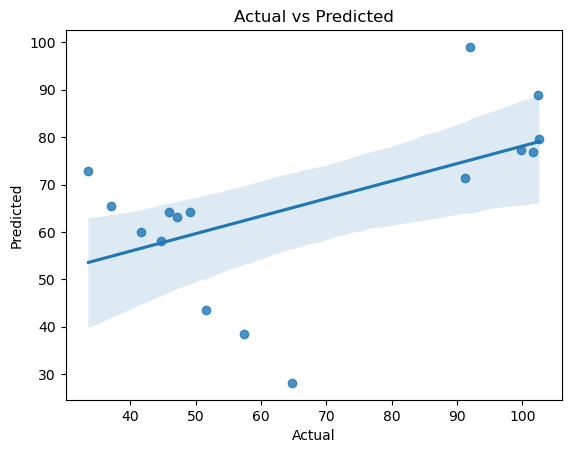

In [56]:
# Plot the actual, compared with predicted. 
# Should be on a 45° incline to show good predictions.
sns.regplot(x="Oil Cost $ (Barrell)", y="predicted", data = test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

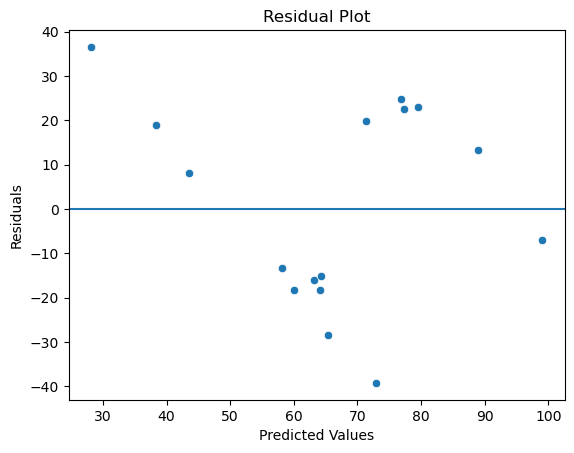

In [57]:
# Plot redsiduals to understand dispersion of outliers.
# Should be centered around 0

residuals = test["Oil Cost $ (Barrell)"] - test["predicted"]
sns.scatterplot(x=test["predicted"], y=residuals, data = test)

plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



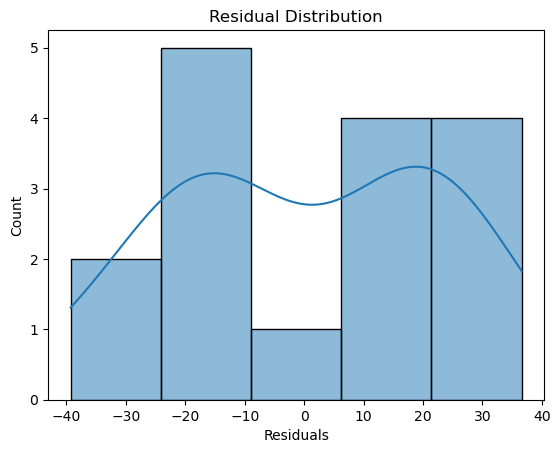

In [58]:
# Plot the distribution of residuals 
# Should look like a bell-curve when correct
sns.histplot(residuals, kde=True)

plt.xlabel("Residuals")
plt.title("Residual Distribution")

plt.show()

--- 
### Operationalise
In the real world, this is where you would draft a report, deliver briefings, implement with automation on production level servers, produce technical documentation and build this into your BAU process. This being a fictional company, we are simply going to create some new data and run this through our model. 

In [ ]:
# Created a dictionary of new data.
new_data = {
    "Oil Cost $ (Barrell)": [100, 200, 72.50, 60, 45.30], # dependent variable
    "S&P Close Price $": [60.50, 65.45, 62.20, 60.50, 65.45] # ndependent variable
}

# Convert the dictionary to a dataframe. 
new_data_df = pd.DataFrame(new_data)
new_data_df.head()


In [59]:
# Create the new independent variable and add constant. 
new_ind = new_data_df["S&P Close Price $"]
new_ind = sm.add_constant(new_ind)
new_ind.head()

,const,S&P Close Price $
0,1.0,60.50
1,1.0,65.45
2,1.0,62.20
3,1.0,60.50
4,1.0,65.45


In [60]:
# Run the new data through the model and generate predictions
output = model.predict(new_ind)
new_data_df["predicted"] = output
new_data_df.head()

,Oil Cost $ (Barrell),S&P Close Price $,predicted
0,100.0,60.50,95.863425
1,200.0,65.45,89.327078
2,72.5,62.20,93.618619
3,60.0,60.50,95.863425
4,45.3,65.45,89.327078
